# Underperforming Products by Region
Dataset: Global Superstore (orders, sales, profit by region/category)

In [1]:
import pandas as pd

df = pd.read_csv('global_superstore.tsv', sep='\t')
df.head()

,Unnamed: 0,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,35180,29165,IN-2014-24531,8/15/14,8/19/14,Standard Class,AS-10285,Alejandro Savely,Corporate,Guangzhou,...,OFF-SU-10001343,Office Supplies,Supplies,"Elite Scissors, High Speed","45,06",2,0,"5,4","3,53",Medium
1,39850,39615,CA-2014-130904,4/12/14,4/17/14,Standard Class,HM-14980,Henry MacAllister,Consumer,Burlington,...,OFF-AR-10000127,Office Supplies,Art,Newell 321,"20,992",8,"0,2","2,3616","2,28",Medium
2,41575,39158,CA-2012-142993,10/12/12,10/17/12,Standard Class,KA-16525,Kelly Andreada,Consumer,Seattle,...,TEC-AC-10003038,Technology,Accessories,Kingston Digital DataTraveler 16GB USB 2.0,"17,9",2,0,"3,401","1,91",Medium
3,12393,2193,MX-2013-169502,6/13/13,6/15/13,Second Class,AJ-10960,Astrea Jones,Consumer,Santo Domingo,...,TEC-AC-10001341,Technology,Accessories,"Enermax Memory Card, USB","183,36",3,"0,2","22,92","25,54",Critical
4,45530,23217,IN-2014-50627,9/14/14,9/18/14,Standard Class,LW-16825,Laurel Workman,Corporate,Jinhua,...,OFF-EN-10001977,Office Supplies,Envelopes,"Cameo Business Envelopes, Recycled","31,5",2,0,"6,9","1,14",Medium


In [2]:
def clean_numeric(col):
    return col.astype(str).str.replace(',', '.', regex=False).astype(float)

for col in ['Sales', 'Profit', 'Discount', 'Shipping Cost']:
    df[col] = clean_numeric(df[col])

df[['Sales', 'Profit', 'Discount', 'Shipping Cost']].dtypes

Sales            float64
Profit           float64
Discount         float64
Shipping Cost    float64
dtype: object

In [3]:
print(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

Unnamed: 0          0
Row ID              0
Order ID            0
Order Date          0
Ship Date           0
Ship Mode           0
Customer ID         0
Customer Name       0
Segment             0
City                0
State               0
Country             0
Postal Code       804
Market              0
Region              0
Product ID          0
Category            0
Sub-Category        0
Product Name        0
Sales               0
Quantity            0
Discount            0
Profit              0
Shipping Cost       0
Order Priority      0
dtype: int64
Duplicate rows: 0


In [4]:
df = df.drop(columns=['Postal Code'])
df.isnull().sum()

Unnamed: 0        0
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
City              0
State             0
Country           0
Market            0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
Shipping Cost     0
Order Priority    0
dtype: int64

In [5]:
import sqlite3

conn = sqlite3.connect('superstore.db')
df.to_sql('orders', conn, if_exists='replace', index=False)

pd.read_sql("SELECT COUNT(*) AS row_count FROM orders", conn)

,row_count
0,1000


In [6]:
query = """
SELECT
    Region,
    "Sub-Category",
    SUM(Sales) AS total_sales,
    SUM(Profit) AS total_profit,
    ROUND(100.0 * SUM(Profit) / SUM(Sales), 2) AS profit_margin_pct,
    COUNT(*) AS order_count
FROM orders
GROUP BY Region, "Sub-Category"
ORDER BY Region, total_profit ASC
"""

region_summary = pd.read_sql(query, conn)
region_summary.head(20)

,Region,Sub-Category,total_sales,total_profit,profit_margin_pct,order_count
0,Africa,Chairs,770.322,-546.198,-70.91,3
1,Africa,Copiers,610.200,-413.010,-67.68,3
2,Africa,Storage,585.351,-186.909,-31.93,12
3,Africa,Machines,363.975,-101.415,-27.86,3
4,Africa,Paper,196.866,-73.014,-37.09,3
5,Africa,Fasteners,87.954,-18.606,-21.15,5
6,Africa,Supplies,129.300,22.110,17.10,3
7,Africa,Accessories,270.168,25.728,9.52,2
8,Africa,Furnishings,165.927,30.717,18.51,4
9,Africa,Labels,193.920,37.140,19.15,7


In [7]:
loss_makers = pd.read_sql("""
SELECT
    Region,
    "Sub-Category",
    SUM(Sales) AS total_sales,
    SUM(Profit) AS total_profit,
    ROUND(100.0 * SUM(Profit) / SUM(Sales), 2) AS profit_margin_pct,
    COUNT(*) AS order_count
FROM orders
GROUP BY Region, "Sub-Category"
HAVING SUM(Profit) < 0
ORDER BY total_profit ASC
""", conn)

loss_makers

,Region,Sub-Category,total_sales,total_profit,profit_margin_pct,order_count
0,Central,Binders,3956.03000,-3349.36030,-84.66,26
1,East,Binders,1618.52400,-644.82780,-39.84,13
2,Central,Tables,4592.51250,-587.54040,-12.79,6
3,Central Asia,Appliances,6505.95000,-552.27000,-8.49,5
4,Africa,Chairs,770.32200,-546.19800,-70.91,3
5,North,Copiers,3626.31224,-498.67776,-13.75,5
6,Africa,Copiers,610.20000,-413.01000,-67.68,3
7,North Asia,Tables,986.20200,-408.61800,-41.43,1
8,EMEA,Phones,1011.92400,-389.94600,-38.54,5
9,West,Machines,269.97000,-386.95700,-143.33,1


In [8]:
low_volume = pd.read_sql("""
WITH subcat_avg AS (
    SELECT
        "Sub-Category",
        AVG(sub_total) AS avg_sales_per_region
    FROM (
        SELECT Region, "Sub-Category", SUM(Sales) AS sub_total
        FROM orders
        GROUP BY Region, "Sub-Category"
    )
    GROUP BY "Sub-Category"
)

SELECT
    o.Region,
    o."Sub-Category",
    SUM(o.Sales) AS total_sales,
    ROUND(a.avg_sales_per_region, 2) AS avg_sales_per_region,
    ROUND(100.0 * SUM(o.Sales) / a.avg_sales_per_region, 1) AS pct_of_average
FROM orders o
JOIN subcat_avg a ON o."Sub-Category" = a."Sub-Category"
GROUP BY o.Region, o."Sub-Category"
HAVING total_sales < a.avg_sales_per_region
ORDER BY pct_of_average ASC
""", conn)

low_volume.head(20)

,Region,Sub-Category,total_sales,avg_sales_per_region,pct_of_average
0,Canada,Binders,6.1200,1072.79,0.6
1,East,Envelopes,2.0400,289.06,0.7
2,Central Asia,Storage,22.5000,1321.21,1.7
3,East,Supplies,14.7200,327.23,4.5
4,Caribbean,Art,33.0240,665.84,5.0
5,Canada,Chairs,148.5000,2431.78,6.1
6,North Asia,Binders,67.2600,1072.79,6.3
7,Central Asia,Binders,72.8100,1072.79,6.8
8,West,Fasteners,11.0880,129.58,8.6
9,Caribbean,Appliances,178.0800,1965.98,9.1


In [9]:
worst_margin = pd.read_sql("""
SELECT
    Region,
    "Sub-Category",
    SUM(Sales) AS total_sales,
    SUM(Profit) AS total_profit,
    ROUND(100.0 * SUM(Profit) / SUM(Sales), 2) AS profit_margin_pct,
    COUNT(*) AS order_count
FROM orders
GROUP BY Region, "Sub-Category"
HAVING order_count >= 3
ORDER BY profit_margin_pct ASC
""", conn)

worst_margin.head(20)

,Region,Sub-Category,total_sales,total_profit,profit_margin_pct,order_count
0,Central,Binders,3956.03000,-3349.36030,-84.66,26
1,Africa,Chairs,770.32200,-546.19800,-70.91,3
2,Africa,Copiers,610.20000,-413.01000,-67.68,3
3,Southeast Asia,Art,374.02740,-233.29260,-62.37,5
4,East,Binders,1618.52400,-644.82780,-39.84,13
5,EMEA,Phones,1011.92400,-389.94600,-38.54,5
6,Africa,Paper,196.86600,-73.01400,-37.09,3
7,Africa,Storage,585.35100,-186.90900,-31.93,12
8,Africa,Machines,363.97500,-101.41500,-27.86,3
9,Africa,Fasteners,87.95400,-18.60600,-21.15,5


In [10]:
combined = pd.read_sql("""
SELECT
    Region,
    "Sub-Category",
    SUM(Sales) AS total_sales,
    SUM(Profit) AS total_profit,
    ROUND(100.0 * SUM(Profit) / SUM(Sales), 2) AS profit_margin_pct,
    COUNT(*) AS order_count,
    CASE WHEN SUM(Profit) < 0 THEN 1 ELSE 0 END AS is_loss_making,
    CASE WHEN 100.0 * SUM(Profit) / SUM(Sales) < 10 THEN 1 ELSE 0 END AS is_low_margin
FROM orders
GROUP BY Region, "Sub-Category"
HAVING order_count >= 3
""", conn)

combined['underperform_score'] = combined['is_loss_making'] + combined['is_low_margin']
combined = combined.sort_values(['underperform_score', 'total_profit'], ascending=[False, True])
combined.head(20)

,Region,Sub-Category,total_sales,total_profit,profit_margin_pct,order_count,is_loss_making,is_low_margin,underperform_score
23,Central,Binders,3956.03000,-3349.36030,-84.66,26,1,1,2
59,East,Binders,1618.52400,-644.82780,-39.84,13,1,1,2
36,Central,Tables,4592.51250,-587.54040,-12.79,6,1,1,2
37,Central Asia,Appliances,6505.95000,-552.27000,-8.49,5,1,1,2
3,Africa,Chairs,770.32200,-546.19800,-70.91,3,1,1,2
72,North,Copiers,3626.31224,-498.67776,-13.75,5,1,1,2
4,Africa,Copiers,610.20000,-413.01000,-67.68,3,1,1,2
54,EMEA,Phones,1011.92400,-389.94600,-38.54,5,1,1,2
116,Southeast Asia,Accessories,1556.93100,-325.50900,-20.91,10,1,1,2
117,Southeast Asia,Art,374.02740,-233.29260,-62.37,5,1,1,2


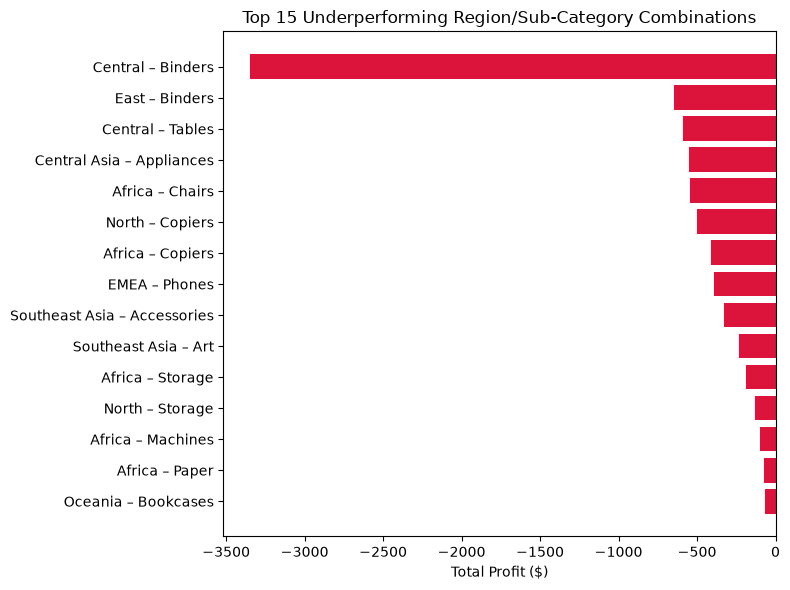

In [15]:
import matplotlib.pyplot as plt

top_n = combined.head(15).copy()
top_n['label'] = top_n['Region'] + ' – ' + top_n['Sub-Category']

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_n['label'], top_n['total_profit'], color='crimson')
ax.set_xlabel('Total Profit ($)')
ax.set_title('Top 15 Underperforming Region/Sub-Category Combinations')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('top_underperformers.png', dpi=150)
plt.show()